In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone
from scipy import stats

In [2]:
# Создаём синтетические данные для классификации
X, y =make_classification(
    n_samples=15000,
    n_features=25,
    n_classes=2,
    n_informative=20,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Параметры бэггинга
n_trees = 23
max_depth = 5

In [3]:
# Реализуем бэггинг
trees = []
for _ in range(n_trees):
    # Формируем бутстрап-выборку (с возвращением)
    indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_bootstrap = X_train[indices]
    y_bootstrap = y_train[indices]

    # Обучите дерево на бутстрап-выборке
    tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    tree.fit(X_bootstrap, y_bootstrap)
    trees.append(tree)

print(trees)

[DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_depth=5, random_state=42), DecisionTreeClassifier(max_

In [33]:
# Предсказания ансамбля (голосование для классификации)
def predict_ensemble(X, trees):
    predictions = np.array([tree.predict(X) for tree in trees])
    # Голосование по большинству
    result = np.round(predictions.mean(axis=0)).astype(int)
    return result

# Оцениваем точность
y_pred = predict_ensemble(X_test, trees)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность ансамбля: {accuracy:.4f}")

# Строим отчёт по всем метрикам
report = classification_report(y_test, y_pred)
print(report)

Точность ансамбля: 0.8200
              precision    recall  f1-score   support

           0       0.87      0.75      0.81      2249
           1       0.78      0.89      0.83      2251

    accuracy                           0.82      4500
   macro avg       0.83      0.82      0.82      4500
weighted avg       0.83      0.82      0.82      4500



In [5]:
# Обучите одно дерево на всей выборке
solo_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
solo_tree.fit(X_train, y_train)

y_pred_solo_tree = solo_tree.predict(X_test)

# Оцените точность одного дерева
solo_tree_accuracy = accuracy_score(y_test, y_pred_solo_tree)
print(f"Точность одного дерева: {solo_tree_accuracy:.4f}")

# Постройте отчёт по всем метрикам
solo_tree_report = classification_report(y_test, y_pred_solo_tree)
print(solo_tree_report)

Точность одного дерева: 0.7751
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      2249
           1       0.75      0.82      0.78      2251

    accuracy                           0.78      4500
   macro avg       0.78      0.78      0.77      4500
weighted avg       0.78      0.78      0.77      4500



In [31]:
# Функция для обучения ансамбля с заданным количеством моделей
def train_ensemble(X, n_trees, max_depth=5):
    trees = []
    for _ in range(n_trees):
        indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
        X_bootstrap = X_train[indices]
        y_bootstrap = y_train[indices]

        tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
        tree.fit(X_bootstrap, y_bootstrap)
        trees.append(tree)
    
    return predict_ensemble(X, trees)

Количество моделей: 1, MSE: 0.2253
Количество моделей: 5, MSE: 0.1753
Количество моделей: 10, MSE: 0.1740
Количество моделей: 20, MSE: 0.1747
Количество моделей: 30, MSE: 0.1764
Количество моделей: 50, MSE: 0.1769
Количество моделей: 75, MSE: 0.1704
Количество моделей: 100, MSE: 0.1771
Количество моделей: 150, MSE: 0.1747
Количество моделей: 200, MSE: 0.1733
Количество моделей: 300, MSE: 0.1736


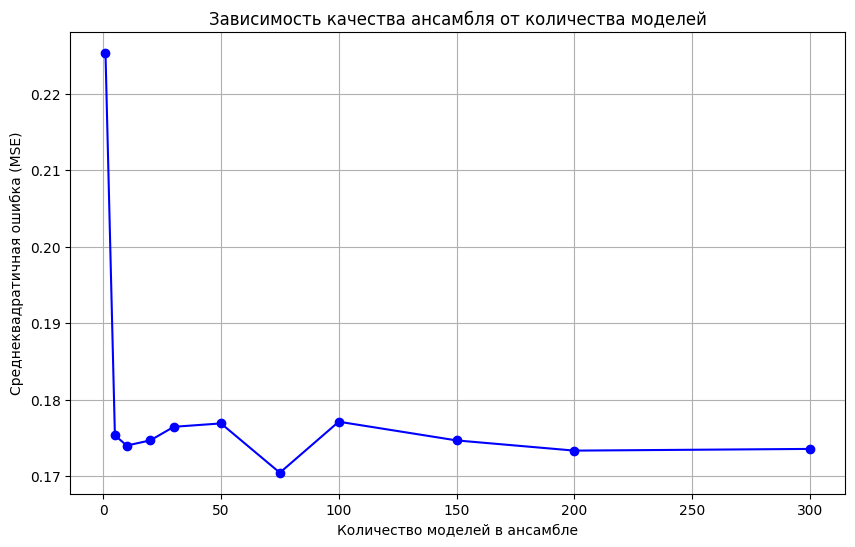

In [ ]:
# Тестируем ансамбли с разным количеством моделей
n_trees_list = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300]
mse_score =[]

for n_trees in n_trees_list:
    y_pred = train_ensemble(X_test, n_trees)
    mse = mean_squared_error(y_test, y_pred)
    mse_score.append(mse)
    print(f"Количество моделей: {n_trees}, MSE: {mse:.4f}")

# Строим график зависимости MSE от количества моделей
plt.figure(figsize=(10, 6))
plt.plot(n_trees_list, mse_score, marker='o', linestyle='-', color='b')
plt.xlabel("Количество моделей в ансамбле")
plt.ylabel("Среднеквадратичная ошибка (MSE)")
plt.title("Зависимость качества ансамбля от количества моделей")
plt.grid(True)
plt.show()

***Сравнение качества работы ансамбля с разными базовыми моделями***
Чтобы понять, как бэггинг ведёт себя при использовании разных базовых моделей, решим задачу классификации экзопланет на основе их характеристик и метрик. Обучение будет выполняться на датасете, который объединяет данные из трёх папок: KOI, K2 и TOI архива NASA Exoplanet Archive.

In [45]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s15_t1_exaplanet_dataset.csv')

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [51]:
# Определяем базовые модели
base_models = {
    'Decision Tree (depth=2)': DecisionTreeClassifier(max_depth=2, random_state=42),
    'Decision Tree (depth=25)': DecisionTreeClassifier(max_depth=25, random_state=42),
    'Logistic Regression': LogisticRegression(solver='sag', max_iter=1000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

In [52]:
# Функция для обучения ансамбля с заданной базовой моделью
def train_ensemble(X_train, y_train, X_eval, base_model, n_trees=50):
    models = []

    for _ in range(n_trees):
        # Формируем бутстрап-выборку
        indices = np.random.choice(len(X_train), size=len(X_train), replace=True)
        X_bootstrap = X_train.iloc[indices]
        y_bootstrap = y_train.iloc[indices]

        # Клонируем базовую модель и обучаем её
        cloned_classifier = clone(base_model)
        cloned_classifier.fit(X_bootstrap, y_bootstrap)
        models.append(cloned_classifier)

    # Предсказания ансамбля (голосование по моде)
    # predictions.shape = (n_trees, n_samples)
    predictions = np.array([model.predict(X_eval) for model in models])

    # Берём моду по каждому объекту (по столбцам)
    mode_result = stats.mode(predictions, axis=0, keepdims=False)
    y_pred = mode_result.mode  # shape = (n_samples,)

    return y_pred

Базовая модель: Decision Tree (depth=2), F1 score: 0.5871
Базовая модель: Decision Tree (depth=25), F1 score: 0.7670


d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\ProjectPython\Sprint15_User_Behavior_Scoring\.ml_env_sprint15\Lib\site-packages\sklearn\linear_model\_sag.py:348: Convergence

Базовая модель: Logistic Regression, F1 score: 0.5039
Базовая модель: KNN (k=5), F1 score: 0.6253


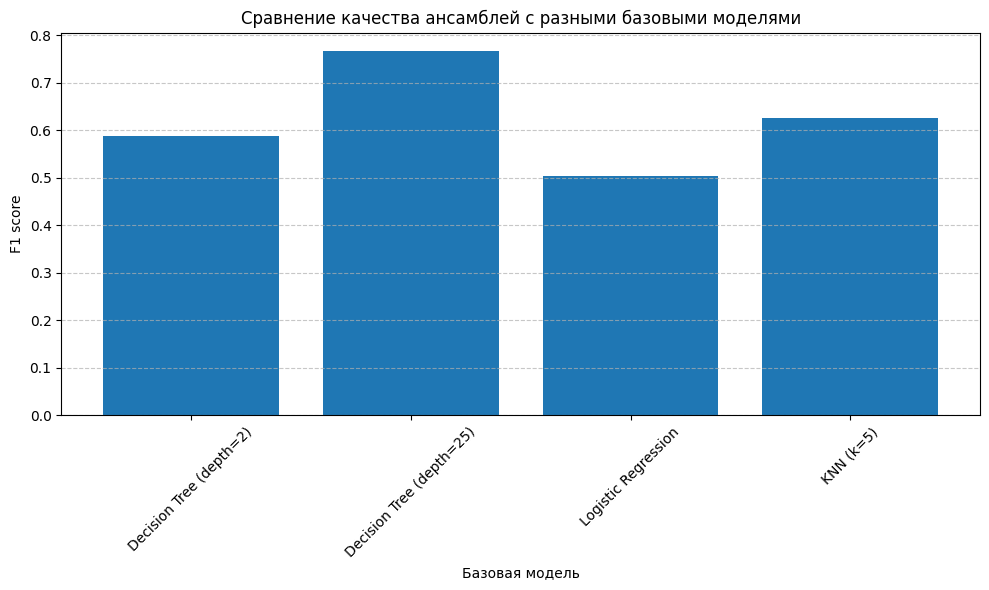

In [53]:
# Тестируем ансамбли с разными базовыми моделями
n_trees = 20
results = {}

for model_name, base_model in base_models.items():
    y_pred = train_ensemble(X_train, y_train, X_test, base_model, n_trees=n_trees)
    f1 = f1_score(y_test, y_pred, average='micro')
    results[model_name] = f1
    print(f'Базовая модель: {model_name}, F1 score: {f1:.4f}')

# Строим график сравнения качества ансамблей
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values())
plt.xlabel('Базовая модель')
plt.ylabel('F1 score')
plt.title('Сравнение качества ансамблей с разными базовыми моделями')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()